# 06: Task Performance

*How reliably does the KG support biological inference?*

This notebook evaluates **task performance** — whether a KG's structure supports accurate biological inference for its intended application. Three sub-metrics are computed using graph-heuristic methods only (no embeddings or training), providing a pure test of structural signal.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Link prediction** | Ability to discriminate known drug–disease indication pairs from type-constrained random negatives | AUROC under type-constrained negative sampling using Adamic-Adar (pre-specified primary heuristic); Common Neighbors and Jaccard reported in supplementary table | Direct AUROC (0–1); no transformation |
| **Neighbourhood retrieval** | Recovery of held-out disease–gene associations within top-ranked graph-proximity candidates | Recall@100: fraction of known disease–gene partners retrieved within the top-100 Adamic-Adar–ranked candidates | Direct proportion (0–1); no transformation |
| **Multi-hop reasoning** | Recovery of known mechanistic target genes as intermediate nodes in drug→gene→disease paths | Hits@100: fraction of known (drug, gene, disease) triplets where the target gene ranks in the top 100 under AA(drug,g) × AA(g,disease) scoring | Direct proportion (0–1); no transformation |
| **Dimension score** | — | — | Equal-weighted mean of link prediction AUROC, Recall@100, and Hits@100 |

**Heuristics (link prediction):** Adamic-Adar is the pre-specified primary heuristic. It down-weights shared neighbours that are high-degree hubs ($\sum_{w \in N(u) \cap N(v)} 1/\log|N(w)|$), making it more biologically motivated than raw common neighbour count. All three heuristics (Common Neighbors, Jaccard, Adamic-Adar) are computed and reported in the supplementary table.

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`) · `data/gold_standards/CTD_chem_gene_ixns.tsv.gz` · `data/gold_standards/CTD_curated_genes_diseases.tsv.gz`

**Outputs:** `results/figures/06_*.{pdf,png}` · `results/task_performance/*.csv` · `results/checkpoints/06_predictive_performance.pkl`

**Dependencies:** `src/loading.py` · `src/graph_utils.py` · `src/scoring.py` · `src/evaluation.py` · `src/negative_sampling.py` · `src/plotting.py`

## Set-up

Three knowledge graphs are evaluated: **Hetionet** (Himmelstein et al., 2017), **DRKG** (Ioannidis et al., 2020), and **PrimeKG** (Chandak et al., 2023). All graphs and node tables are loaded using the shared `src/` loading utilities and evaluated under identical conditions. The same random seed (`seed = 42`) and negative sampling strategies are used throughout.

In [1]:
# Imports
import sys, os, warnings, pickle
warnings.filterwarnings('ignore')
from pathlib import Path

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import time
from tqdm.notebook import tqdm
from collections import defaultdict, Counter
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

from src.plotting          import setup_style, clean_ax, save_fig, panel_label, TEXT_COLOR, TICK_COLOR, ALERT_RED, KG_PALETTE, HEURISTIC_COLORS, HEATMAP_CMAP
from src.loading           import find_config, load_config, load_kg
from src.graph_utils       import build_graph, build_lookup_maps, find_node
from src.scoring           import SCORERS
from src.evaluation        import compute_metrics
from src.negative_sampling import generate_negatives

setup_style()

In [2]:
# Config and paths
config  = load_config(find_config(_root))
params  = config['analysis_params']
BASE    = config['_base_dir']
FIGS    = BASE / 'results' / 'figures';        FIGS.mkdir(parents=True, exist_ok=True)

In [3]:
# Plot utilities
def _style_left_spine(ax):
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)

In [4]:
# ── Bootstrap CI and permutation test utilities ──────────────────────
N_BOOT = 1000
BOOT_RNG = np.random.RandomState(params.get('random_seed', 42))

def bootstrap_metric_ci(scores_arr, labels_arr, metric_fn, n_boot=N_BOOT,
                        rng=BOOT_RNG, stratified=True):
    """Percentile bootstrap 95% CI for an arbitrary metric.

    Parameters
    ----------
    scores_arr : np.ndarray
    labels_arr : np.ndarray (binary)
    metric_fn  : callable(scores, labels) -> float
    stratified : bool — if True, resample positives and negatives separately
                 to preserve class ratio in every bootstrap sample.

    Returns
    -------
    (point, ci_lo, ci_hi) or (nan, nan, nan)
    """
    scores_arr = np.asarray(scores_arr, dtype=float)
    labels_arr = np.asarray(labels_arr, dtype=int)
    n = len(scores_arr)
    pos_idx = np.where(labels_arr == 1)[0]
    neg_idx = np.where(labels_arr == 0)[0]
    if len(pos_idx) < 2 or len(neg_idx) < 2:
        return np.nan, np.nan, np.nan

    boots = []
    for _ in range(n_boot):
        if stratified:
            bi_pos = rng.choice(pos_idx, size=len(pos_idx), replace=True)
            bi_neg = rng.choice(neg_idx, size=len(neg_idx), replace=True)
            bi = np.concatenate([bi_pos, bi_neg])
        else:
            bi = rng.randint(0, n, n)
        b_labels = labels_arr[bi]
        if b_labels.sum() == 0 or b_labels.sum() == len(b_labels):
            continue
        try:
            boots.append(metric_fn(scores_arr[bi], b_labels))
        except Exception:
            continue
    if len(boots) < 10:
        return np.nan, np.nan, np.nan
    point = metric_fn(scores_arr, labels_arr)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(point), float(lo), float(hi)


def permutation_test_auroc(scores_a, labels_a, scores_b, labels_b,
                           n_perm=1000, rng=BOOT_RNG):
    """Two-sided permutation test for difference in AUROC between two KGs.

    Null hypothesis: the two sets of (scores, labels) come from systems
    with equal AUROC. We permute the assignment of score vectors to KGs
    and measure the fraction of permutations where |delta_AUROC| >= observed.

    Returns
    -------
    p_value : float
    """
    obs_a = roc_auc_score(labels_a, scores_a)
    obs_b = roc_auc_score(labels_b, scores_b)
    obs_diff = abs(obs_a - obs_b)

    # Pool scores and labels
    pooled_scores = np.concatenate([scores_a, scores_b])
    pooled_labels = np.concatenate([labels_a, labels_b])
    n_a = len(scores_a)
    n_total = len(pooled_scores)

    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(n_total)
        pa_s, pa_l = pooled_scores[perm[:n_a]], pooled_labels[perm[:n_a]]
        pb_s, pb_l = pooled_scores[perm[n_a:]], pooled_labels[perm[n_a:]]
        # Skip degenerate splits
        if pa_l.sum() == 0 or pa_l.sum() == len(pa_l):
            continue
        if pb_l.sum() == 0 or pb_l.sum() == len(pb_l):
            continue
        try:
            d = abs(roc_auc_score(pa_l, pa_s) - roc_auc_score(pb_l, pb_s))
        except Exception:
            continue
        if d >= obs_diff:
            count += 1
    return count / n_perm

print(f'Bootstrap utilities loaded: N_BOOT={N_BOOT}, stratified resampling')


Bootstrap utilities loaded: N_BOOT=1000, stratified resampling


### Loading

In [5]:
# Free any KG/graph state left over from a previous notebook (prevents
# the ~150 GB OOM that hit when running notebooks back-to-back in one kernel).
for _v in ('kgs', 'graphs', 'maps', 'preps'):
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()

# Load KGs
KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

kgs = {}
for name in KG_NAMES:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

LOADED = [n for n in KG_NAMES if n in kgs and config['knowledge_graphs'].get(n, {}).get('relations')]
print(f'\nLoaded: {LOADED}')

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types
  matrix: loading from cache _cache_matrix_88f004a4_kg.parquet / _cache_matrix_88f004a4_nodes.parquet
  matrix: cached load — 2,850,122 nodes, 41,595,079 edges
matrix      :   41,595,079 edges  2,850,122 nodes    76 relation types

Loaded: ['primekg', 'hetionet', 'drkg', 'openbilink', 'biokg', 'matrix']


In [6]:
# Build graphs and lookup maps
graphs, maps = {}, {}
for name, data in kgs.items():
    G            = build_graph(data['kg'], data['nodes'])
    m            = build_lookup_maps(data['nodes'])
    m['node_id_map'] = dict(zip(data['nodes']['idx'], data['nodes']['id']))
    # id_to_idx: bare-id lookup (WARNING: PrimeKG IDs can collide across types).
    # Use uid_to_idx (type/id keyed) or filter by node_type_map for safe lookups.
    m['id_to_idx']   = dict(zip(data['nodes']['id'],  data['nodes']['idx']))
    if 'uid' in data['nodes'].columns:
        m['uid_to_idx'] = dict(zip(data['nodes']['uid'], data['nodes']['idx']))
    graphs[name] = G
    maps[name]   = m
    print(f'{name:12s}: {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges')

primekg     : 129,375 nodes  4,049,642 edges
hetionet    : 47,031 nodes  2,107,709 edges
drkg        : 97,238 nodes  4,400,766 edges
openbilink  : 185,929 nodes  3,200,327 edges
biokg       : 105,524 nodes  2,043,846 edges
matrix      : 2,850,122 nodes  25,605,352 edges


In [7]:
# Per-KG entity type and relation config - read from config, not hardcoded
KG_CONFIG = {
    name: config['knowledge_graphs'][name]
    for name in LOADED
}

# Convenience accessors - fail loudly if a key is missing from config
def kg_drug_type(name):    return KG_CONFIG[name]['entity_types']['Drug']
def kg_disease_type(name): return KG_CONFIG[name]['entity_types']['Disease']
def kg_gene_type(name):    return KG_CONFIG[name]['entity_types'].get('Gene/Protein')

def kg_indication_rels(name):
    return [KG_CONFIG[name]['relations']['drug_disease']['relation']]

def kg_drug_target_rels(name):
    """Return list of drug-target relation names (handles singular 'relation'
    or plural 'relations' in config — whichever the KG uses)."""
    cfg = KG_CONFIG[name]['relations'].get('drug_target', {})
    if 'relations' in cfg:   # plural list (e.g. openbilink)
        return cfg['relations']
    if 'relation' in cfg:   # singular string (e.g. primekg, hetionet)
        return [cfg['relation']]
    return []

**Negative sampling protocol** (Kotnis & Nastase, 2017): Drug–disease indication pairs (`indication` + `off-label use` edges) form the positive set. A 90/10 train/test split is used; test edges are removed from the graph before scoring to prevent data leakage. Negatives are generated under three strategies of increasing difficulty:

| Strategy | Construction | Purpose |
|---|---|---|
| **Random** | Uniform random drug–disease pairs not in positive set | Upper-bound estimate; easy to discriminate |
| **Type-constrained** | Random pairs restricted to drug and disease node types | Removes trivial type-based discrimination |
| **Shared-target** | Drug–disease pairs sharing at least one protein target | Hardest; tests whether the KG can distinguish therapeutically similar but non-indicated pairs |


In [8]:
# Extract positive pairs, entity sets, and drug-target maps
kg_pos_pairs, kg_entity_sets, kg_drug_targets = {}, {}, {}

for name, data in kgs.items():
    kg, nodes = data['kg'], data['nodes']
    dt, dis_t, gt = kg_drug_type(name), kg_disease_type(name), kg_gene_type(name)

    # Positive drug-disease indication pairs (vectorized - avoids
    # .iterrows() over potentially millions of rows on Matrix)
    ind_edges = kg[kg['relation'].isin(kg_indication_rels(name))]
    if not ind_edges.empty:
        _xt = ind_edges['x_type'].to_numpy()
        _yt = ind_edges['y_type'].to_numpy()
        _xi = ind_edges['x_index'].to_numpy()
        _yi = ind_edges['y_index'].to_numpy()
        _fwd  = (_xt == dt)     & (_yt == dis_t)
        _rev  = (_xt == dis_t)  & (_yt == dt)
        _keep = _fwd | _rev
        _drug = np.where(_fwd, _xi, _yi)
        _dis  = np.where(_fwd, _yi, _xi)
        pos_pairs = set(zip(_drug[_keep].tolist(), _dis[_keep].tolist()))
    else:
        pos_pairs = set()
    kg_pos_pairs[name] = list(pos_pairs)

    # Entity index sets
    kg_entity_sets[name] = {
        etype: set(nodes[nodes['type'] == t]['idx'])
        for etype, t in [('drug', dt), ('disease', dis_t), ('gene', gt)]
        if t is not None
    }

    # Drug-target map: drug_idx -> set of gene_idx (vectorized).
    # Uses kg_drug_target_rels() which handles both singular and plural config.
    dtmap = defaultdict(set)
    dtrels = kg_drug_target_rels(name)
    if dtrels:
        _dtsub = kg[kg['relation'].isin(dtrels)]
        if not _dtsub.empty:
            _xt = _dtsub['x_type'].to_numpy()
            _xi = _dtsub['x_index'].to_numpy()
            _yi = _dtsub['y_index'].to_numpy()
            _is_fwd = (_xt == dt)
            _drug = np.where(_is_fwd, _xi, _yi).tolist()
            _gene = np.where(_is_fwd, _yi, _xi).tolist()
            for _d, _g in zip(_drug, _gene):
                dtmap[_d].add(_g)
    kg_drug_targets[name] = dtmap

    print(f'{name:12s}: {len(pos_pairs):,} indication pairs  '
          f'drugs={len(kg_entity_sets[name].get("drug", {})):,}  '
          f'diseases={len(kg_entity_sets[name].get("disease", {})):,}  '
          f'genes={len(kg_entity_sets[name].get("gene", {})):,}  '
          f'drugs-with-targets={len(dtmap):,}')

primekg     : 9,388 indication pairs  drugs=7,957  diseases=17,080  genes=27,671  drugs-with-targets=6,282
hetionet    : 755 indication pairs  drugs=1,552  diseases=137  genes=20,945  drugs-with-targets=1,389
drkg        : 4,968 indication pairs  drugs=24,313  diseases=5,103  genes=39,220  drugs-with-targets=7,565
openbilink  : 7,164 indication pairs  drugs=78,592  diseases=9,510  genes=19,902  drugs-with-targets=66,346
biokg       : 66,867 indication pairs  drugs=8,805  diseases=5,812  genes=59,204  drugs-with-targets=6,845
matrix      : 383,361 indication pairs  drugs=1,719,600  diseases=26,143  genes=877,358  drugs-with-targets=1,244,439


In [9]:
# Train/test split and training graph construction
TRAIN_RATIO = params.get('train_ratio', 0.9)
rng         = np.random.RandomState(params.get('random_seed', 42))

kg_splits, kg_graphs_train = {}, {}

for name in LOADED:
    pos   = kg_pos_pairs[name]
    idx   = rng.permutation(len(pos))
    split = int(TRAIN_RATIO * len(pos))
    train_pos = [pos[i] for i in idx[:split]]
    test_pos  = [pos[i] for i in idx[split:]]

    kg_splits[name] = {
        'train_pos':     train_pos,
        'test_pos':      test_pos,
        'train_pos_set': set(train_pos),
        'test_pos_set':  set(test_pos),
        'all_pos_set':   set(pos),
    }

    # Scale-aware: G.copy() is fine for small KGs but each copy of Matrix's
    # ~30 GB graph would push 48 GB hosts into swap. For huge graphs use a
    # subgraph_view that hides test edges via a lazy edge filter — no copy.
    if graphs[name].number_of_nodes() > 1_000_000:
        test_edge_set = frozenset((min(d,dis), max(d,dis)) for d, dis in test_pos)
        G_train = nx.subgraph_view(
            graphs[name],
            filter_edge=lambda u, v: (min(u,v), max(u,v)) not in test_edge_set)
    else:
        G_train = graphs[name].copy()
        G_train.remove_edges_from([(d, dis) for d, dis in test_pos if G_train.has_edge(d, dis)])
    kg_graphs_train[name] = G_train
    print(f'{name:12s}: train={len(train_pos):,}  test={len(test_pos):,}  '
          f'graph edges={G_train.number_of_edges():,}')

primekg     : train=8,449  test=939  graph edges=4,048,703
hetionet    : train=679  test=76  graph edges=2,107,633
drkg        : train=4,471  test=497  graph edges=4,400,269
openbilink  : train=6,447  test=717  graph edges=3,199,610
biokg       : train=60,180  test=6,687  graph edges=2,037,159
matrix      : train=345,024  test=38,337  graph edges=25,567,015


In [10]:
# Negative sampling per strategy
NEG_RATIO    = params.get('neg_ratio', 1)
STRATEGIES   = params.get('neg_strategies', ['random', 'type-constrained', 'shared-target'])
STRAT_LABELS = {'random': 'Random', 'type-constrained': 'Type-constrained', 'shared-target': 'Shared-target'}

kg_negatives = {}
for name in LOADED:
    sp, ents = kg_splits[name], kg_entity_sets[name]
    n_neg    = len(sp['test_pos']) * NEG_RATIO
    neg      = {
        strat: generate_negatives(
            sp['test_pos'], n_neg, strat,
            ents['drug'], ents['disease'],
            kg_drug_targets[name], maps[name]['node_name_map'],
            sp['all_pos_set'], rng)
        for strat in STRATEGIES
    }
    kg_negatives[name] = neg
    print(f'{name:12s}: ' + '  '.join(f'{s}={len(neg[s]):,}' for s in STRATEGIES))

primekg     : random=4,695  type-constrained=4,695  shared-target=4,695
hetionet    : random=380  type-constrained=380  shared-target=380
drkg        : random=2,485  type-constrained=2,485  shared-target=2,485
openbilink  : random=3,585  type-constrained=3,585  shared-target=3,585
biokg       : random=33,435  type-constrained=33,435  shared-target=33,435
matrix      : random=191,685  type-constrained=191,685  shared-target=191,685


## 1. Link Prediction

Predict whether a therapeutic relationship exists between a drug and a disease using three graph-proximity heuristics — Common Neighbors, Jaccard, and Adamic-Adar — evaluated under each negative-sampling strategy.

**Heuristics:**

| Heuristic | Formula | Intuition |
|---|---|---|
| **Common Neighbors** | $\|N(u) \cap N(v)\|$ | Pairs with many shared neighbours are more likely linked |
| **Jaccard** | $\|N(u) \cap N(v)\| / \|N(u) \cup N(v)\|$ | Normalises by neighbourhood size to reduce hub bias |
| **Adamic-Adar** | $\sum_{w \in N(u) \cap N(v)} 1 / \log\|N(w)\|$ | Down-weights shared neighbours that are high-degree hubs |

**Metrics:** AUROC and AUPRC measure ranking quality across all thresholds; MRR and Hits@10 measure rank position of true positives.

In [11]:
# Link prediction evaluation — with bootstrap 95% CIs
PRIMARY_HEURISTIC = 'Adamic-Adar'        # pre-specified; not selected post-hoc
ANCHOR_STRAT      = 'type-constrained'   # primary negative-sampling strategy
link_results = {}
link_raw     = {}   # store raw (scores, labels) arrays for bootstrap & permutation tests

for name in LOADED:
    G_train = kg_graphs_train[name]
    sp, neg = kg_splits[name], kg_negatives[name]

    print(f'\n{name}')
    print(f'  {"Heuristic":<20s}  {"Neg. Strategy":<20s}  {"AUROC":>7s}  {"95% CI":>16s}  '
          f'{"AUPRC":>7s}  {"95% CI":>16s}')
    print(f'  ' + '-' * 96)

    for heuristic, scorer in SCORERS.items():
        for strat in STRATEGIES:
            if len(sp['test_pos']) == 0 or len(neg[strat]) == 0:
                continue
            pairs  = sp['test_pos'] + neg[strat]
            labels = np.array([1] * len(sp['test_pos']) + [0] * len(neg[strat]))
            if len(set(labels)) < 2:
                continue
            scores = np.array(scorer(G_train, pairs))
            m      = compute_metrics(scores, labels)
            m.update({'heuristic': heuristic, 'neg_strategy': strat})

            # Bootstrap CIs for AUROC and AUPRC
            _, auroc_lo, auroc_hi = bootstrap_metric_ci(
                scores, labels, lambda s, l: roc_auc_score(l, s))
            _, auprc_lo, auprc_hi = bootstrap_metric_ci(
                scores, labels, lambda s, l: average_precision_score(l, s))
            m['auroc_ci_lo'] = auroc_lo
            m['auroc_ci_hi'] = auroc_hi
            m['auprc_ci_lo'] = auprc_lo
            m['auprc_ci_hi'] = auprc_hi

            link_results[(name, heuristic, strat)] = m
            link_raw[(name, heuristic, strat)]     = (scores, labels)

            print(f'  {heuristic:<20s}  {strat:<20s}  {m["auroc"]:7.4f}  '
                  f'[{auroc_lo:.4f}, {auroc_hi:.4f}]  '
                  f'{m["auprc"]:7.4f}  [{auprc_lo:.4f}, {auprc_hi:.4f}]')



primekg
  Heuristic             Neg. Strategy           AUROC            95% CI    AUPRC            95% CI
  ------------------------------------------------------------------------------------------------
  Common Neighbors      random                 0.9453  [0.9357, 0.9550]   0.8534  [0.8294, 0.8757]
  Common Neighbors      type-constrained       0.9454  [0.9353, 0.9547]   0.8522  [0.8297, 0.8760]
  Common Neighbors      shared-target          0.9230  [0.9125, 0.9333]   0.7407  [0.7098, 0.7678]
  Jaccard               random                 0.9451  [0.9358, 0.9543]   0.8499  [0.8244, 0.8740]
  Jaccard               type-constrained       0.9446  [0.9345, 0.9536]   0.8441  [0.8158, 0.8684]
  Jaccard               shared-target          0.9277  [0.9169, 0.9376]   0.7618  [0.7326, 0.7910]
  Adamic-Adar           random                 0.9463  [0.9370, 0.9562]   0.8630  [0.8392, 0.8859]
  Adamic-Adar           type-constrained       0.9464  [0.9359, 0.9555]   0.8620  [0.8371, 0.8862]
 

In [12]:
# ── Link prediction: CI summary table (primary heuristic, type-constrained) ──
print(f'\n{"KG":12s}  {"AUROC":>7s}  {"95% CI":>16s}  {"AUPRC":>7s}  {"95% CI":>16s}')
print('-' * 68)
for name in LOADED:
    r = link_results.get((name, PRIMARY_HEURISTIC, ANCHOR_STRAT), {})
    if r:
        print(f'{name:12s}  {r["auroc"]:7.4f}  [{r["auroc_ci_lo"]:.4f}, {r["auroc_ci_hi"]:.4f}]  '
              f'{r["auprc"]:7.4f}  [{r["auprc_ci_lo"]:.4f}, {r["auprc_ci_hi"]:.4f}]')

# ── Pairwise permutation tests (Bonferroni-corrected) ────────────────
from itertools import combinations
n_pairs = len(list(combinations(LOADED, 2)))  # 15 for 6 KGs

print(f'\nPairwise permutation test for AUROC difference ({PRIMARY_HEURISTIC}, {ANCHOR_STRAT})')
print(f'Bonferroni correction for {n_pairs} comparisons (alpha=0.05 → threshold={0.05/n_pairs:.4f})\n')

perm_pvals = {}
for kg_a, kg_b in combinations(LOADED, 2):
    raw_a = link_raw.get((kg_a, PRIMARY_HEURISTIC, ANCHOR_STRAT))
    raw_b = link_raw.get((kg_b, PRIMARY_HEURISTIC, ANCHOR_STRAT))
    if raw_a is None or raw_b is None:
        perm_pvals[(kg_a, kg_b)] = np.nan
        continue
    p = permutation_test_auroc(raw_a[0], raw_a[1], raw_b[0], raw_b[1],
                               n_perm=1000, rng=BOOT_RNG)
    p_corr = min(p * n_pairs, 1.0)   # Bonferroni
    perm_pvals[(kg_a, kg_b)] = p_corr
    sig = '***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else 'n.s.'
    auroc_a = link_results[(kg_a, PRIMARY_HEURISTIC, ANCHOR_STRAT)]['auroc']
    auroc_b = link_results[(kg_b, PRIMARY_HEURISTIC, ANCHOR_STRAT)]['auroc']
    print(f'  {kg_a:12s} vs {kg_b:12s}  '
          f'ΔAUROC={auroc_a - auroc_b:+.4f}  '
          f'p_bonf={p_corr:.4f}  {sig}')

# Build p-value matrix for checkpoint
pval_matrix = pd.DataFrame(np.nan, index=LOADED, columns=LOADED)
for (a, b), p in perm_pvals.items():
    pval_matrix.loc[a, b] = p
    pval_matrix.loc[b, a] = p
for name in LOADED:
    pval_matrix.loc[name, name] = 1.0

print(f'\nBonferroni-corrected p-value matrix:')
print(pval_matrix.round(4).to_string())



KG              AUROC            95% CI    AUPRC            95% CI
--------------------------------------------------------------------
primekg        0.9464  [0.9359, 0.9555]   0.8620  [0.8371, 0.8862]
hetionet       0.8745  [0.8246, 0.9166]   0.6543  [0.5515, 0.7609]
drkg           0.9285  [0.9117, 0.9431]   0.8359  [0.8032, 0.8657]
openbilink     0.7596  [0.7418, 0.7785]   0.5988  [0.5701, 0.6320]
biokg          0.8980  [0.8933, 0.9027]   0.7790  [0.7698, 0.7885]
matrix         0.9959  [0.9955, 0.9964]   0.9922  [0.9915, 0.9930]

Pairwise permutation test for AUROC difference (Adamic-Adar, type-constrained)
Bonferroni correction for 15 comparisons (alpha=0.05 → threshold=0.0033)

  primekg      vs hetionet      ΔAUROC=+0.0718  p_bonf=0.0150  *
  primekg      vs drkg          ΔAUROC=+0.0179  p_bonf=0.7050  n.s.
  primekg      vs openbilink    ΔAUROC=+0.1868  p_bonf=0.0000  ***
  primekg      vs biokg         ΔAUROC=+0.0484  p_bonf=0.0000  ***
  primekg      vs matrix        ΔAUROC=-

  → Saved: 06_link_prediction_heatmap.pdf / .png


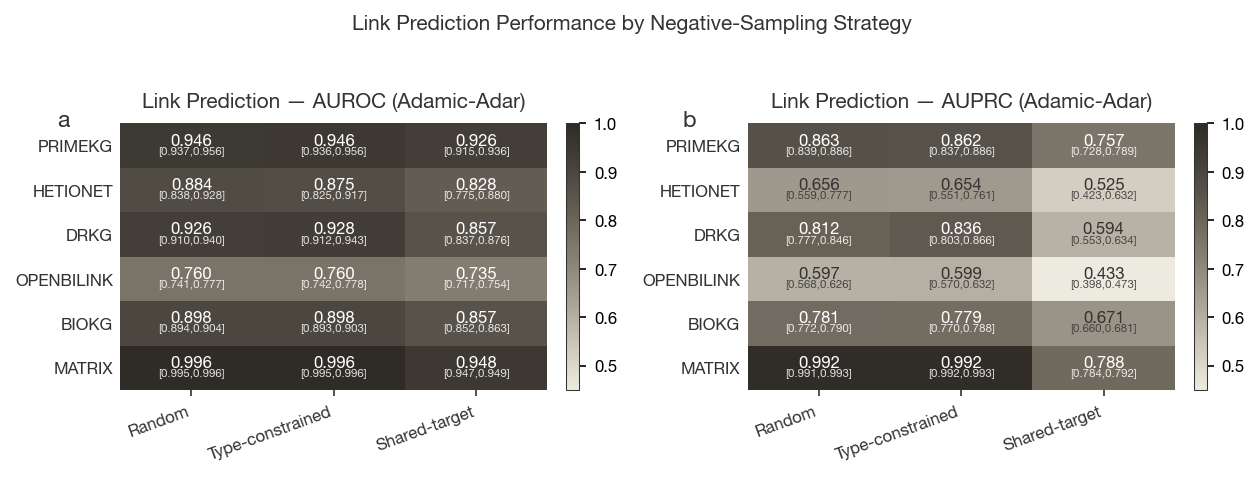

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.0))

for ax, (metric, letter) in zip(axes, [('auroc', 'a'), ('auprc', 'b')]):
    data = np.array([
        [link_results.get((name, PRIMARY_HEURISTIC, strat), {}).get(metric, np.nan)
         for strat in STRATEGIES]
        for name in LOADED
    ])
    im = ax.pcolormesh(data, cmap=HEATMAP_CMAP, vmin=0.45, vmax=1.0,
                       edgecolors='none', linewidth=0, antialiased=False)
    ax.set_xticks([x + 0.5 for x in range(len(STRATEGIES))])
    ax.set_xticklabels([STRAT_LABELS[s] for s in STRATEGIES], fontsize=8,
                       rotation=20, ha='right')
    ax.set_yticks([y + 0.5 for y in range(len(LOADED))])
    ax.set_yticklabels([n.upper() for n in LOADED], fontsize=9)
    ax.tick_params(length=0, which='both')
    ax.grid(False, which='both')
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_visible(False)
    # Annotate with point estimate and CI
    for i, name in enumerate(LOADED):
        for j, strat in enumerate(STRATEGIES):
            r = link_results.get((name, PRIMARY_HEURISTIC, strat), {})
            val = r.get(metric, np.nan)
            ci_lo = r.get(f'{metric}_ci_lo', np.nan)
            ci_hi = r.get(f'{metric}_ci_hi', np.nan)
            if not np.isnan(val):
                txt_color = 'white' if val > 0.7 else TEXT_COLOR
                ax.text(j + 0.5, i + 0.38, f'{val:.3f}', ha='center', va='center',
                        fontsize=8, fontweight='bold', color=txt_color)
                if not np.isnan(ci_lo):
                    ax.text(j + 0.5, i + 0.62, f'[{ci_lo:.3f},{ci_hi:.3f}]',
                            ha='center', va='center', fontsize=5.5, color=txt_color, alpha=0.85)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    clean_ax(ax, title=f'Link Prediction — {metric.upper()} (Adamic-Adar)')
    panel_label(ax, letter)

plt.suptitle('Link Prediction Performance by Negative-Sampling Strategy',
             fontsize=10, fontweight='bold', y=1.04, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '06_link_prediction_heatmap')
plt.show()


  → Saved: 06_link_prediction_pr.pdf / .png


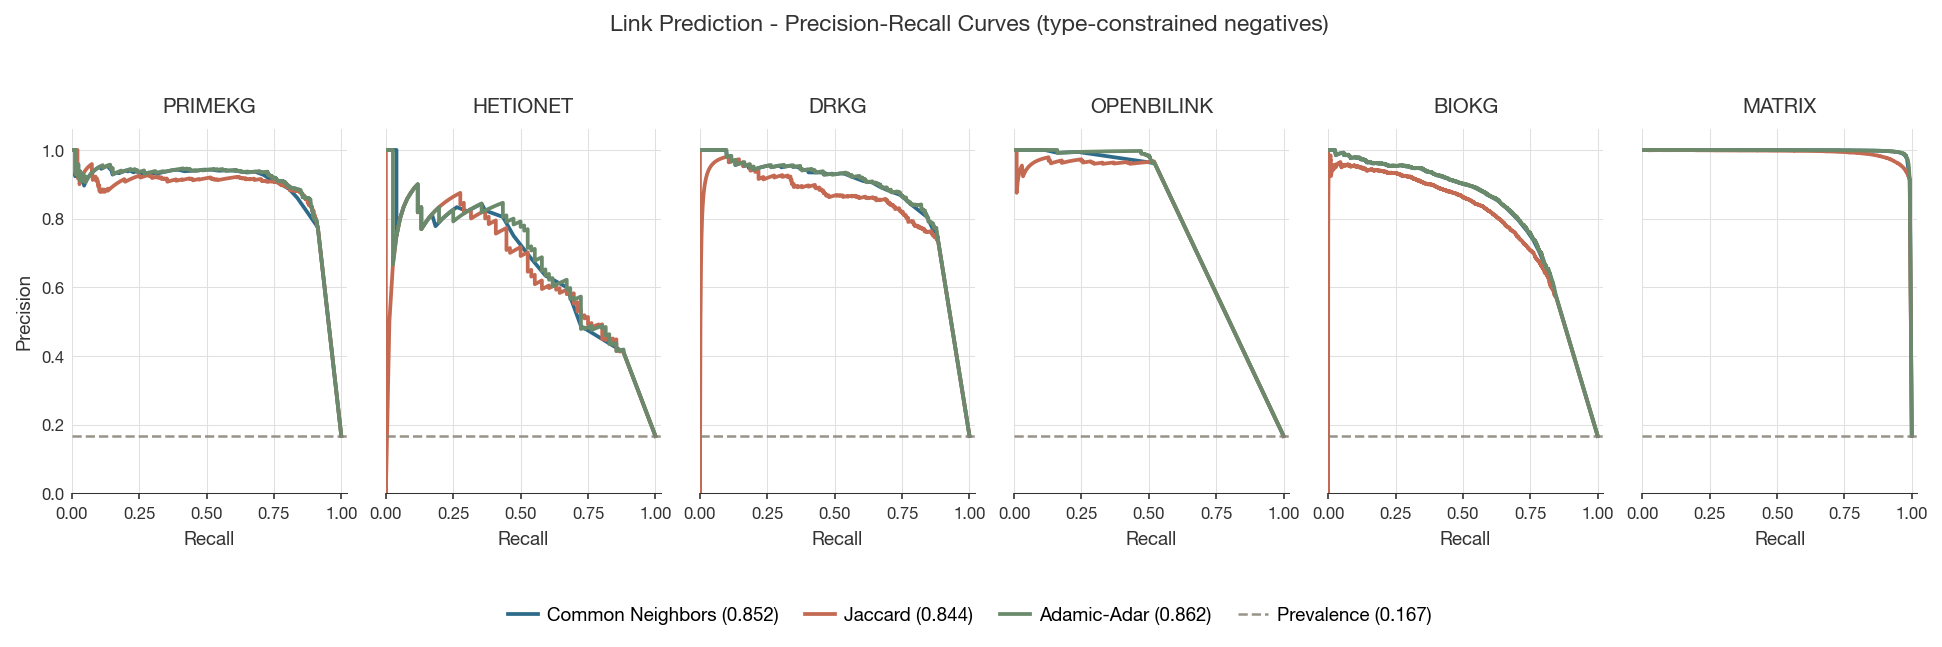

In [14]:
fig, axes = plt.subplots(1, len(LOADED), figsize=(13, 3.8), sharey=True)  # ← was (7.2, 2.6)
if len(LOADED) == 1:
    axes = [axes]

for ax, name in zip(axes, LOADED):
    sp, neg  = kg_splits[name], kg_negatives[name]
    pairs    = sp['test_pos'] + neg[ANCHOR_STRAT]
    labels   = [1] * len(sp['test_pos']) + [0] * len(neg[ANCHOR_STRAT])
    baseline = len(sp['test_pos']) / len(pairs)

    for heuristic in SCORERS:
        scores       = SCORERS[heuristic](kg_graphs_train[name], pairs)
        prec, rec, _ = precision_recall_curve(labels, scores)
        auprc        = link_results[(name, heuristic, ANCHOR_STRAT)]['auprc']
        ax.plot(rec, prec,
                color=HEURISTIC_COLORS.get(heuristic, '#9e9288'),
                lw=1.8, label=f'{heuristic} ({auprc:.3f})')   # ← lw 1.6 → 1.8

    ax.axhline(baseline, color='#868074', ls='--', lw=1.2, alpha=0.85,
               label=f'Prevalence ({baseline:.3f})')
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.06)
    _style_left_spine(ax)
    clean_ax(ax, title=name.upper(), xlabel='Recall',
             ylabel='Precision' if ax == axes[0] else '')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=4,
    fontsize=9,            # ← was 7.5
    frameon=False,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.4,
)

plt.suptitle('Link Prediction - Precision-Recall Curves (type-constrained negatives)',
             fontsize=11, fontweight='bold', y=1.04, color=TEXT_COLOR)  # ← fontsize 10 → 11
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
save_fig(fig, FIGS, '06_link_prediction_pr')
plt.show()

## 2. Neighbourhood Retrieval

Given a disease, rank all candidate genes/proteins by their likelihood of being therapeutic targets. This tests whether the KG's network structure encodes disease–gene associations beyond what is explicitly labelled.

**Protocol.** Leave-one-out evaluation — for each disease with $\geq 5$ known gene targets, one target is held out and ranked against the full pool of candidate genes using Adamic-Adar. **Recall@K** is the fraction of held-out targets recovered in the top K, reported for K = 10, 50, 100. **MRR** (mean reciprocal rank) summarises the average rank position.

A random baseline would achieve Recall@10 $\approx 10 / N_{\text{genes}} \approx 0.04\%$, so values above 1% represent meaningful enrichment.

In [15]:
# Build disease-target ground truth for each KG using entity-type filtering
# (more robust than relation-name filtering since disease-gene relation names vary across KGs)
kg_disease_targets, kg_gene_lists = {}, {}

for name, data in kgs.items():
    kg, nodes = data['kg'], data['nodes']
    dt, dis_t, gt = kg_drug_type(name), kg_disease_type(name), kg_gene_type(name)

    dg_edges = kg[
        ((kg['x_type'] == dis_t) & (kg['y_type'] == gt)) |
        ((kg['x_type'] == gt)    & (kg['y_type'] == dis_t))
    ]
    dis_tgts = defaultdict(set)
    for _, row in dg_edges.iterrows():
        if row['x_type'] == dis_t:
            dis_tgts[row['x_index']].add(row['y_index'])
        else:
            dis_tgts[row['y_index']].add(row['x_index'])

    eligible = {d: t for d, t in dis_tgts.items() if len(t) >= 5}
    gene_list = sorted(kg_entity_sets[name].get('gene', set()))

    kg_disease_targets[name] = eligible
    kg_gene_lists[name]      = gene_list
    print(f'{name:12s}: diseases with >=5 targets={len(eligible):,}  candidate gene pool={len(gene_list):,}')

primekg     : diseases with >=5 targets=1,930  candidate gene pool=27,671
hetionet    : diseases with >=5 targets=121  candidate gene pool=20,945
drkg        : diseases with >=5 targets=1,426  candidate gene pool=39,220
openbilink  : diseases with >=5 targets=1,771  candidate gene pool=19,902
biokg       : diseases with >=5 targets=2,468  candidate gene pool=59,204
matrix      : diseases with >=5 targets=13,148  candidate gene pool=877,358


In [16]:
# Free per-KG edge DataFrames - downstream cells operate on graphs/maps/
# kg_pos_pairs/kg_drug_targets/kg_disease_targets, not the raw edge tables.
# Releases ~10 GB across the 6 KGs (esp. Matrix).
for _name in list(kgs):
    kgs[_name].pop('kg', None)
import gc; gc.collect()
print('Released kgs[*][\'kg\'] DataFrames.')

Released kgs[*]['kg'] DataFrames.


In [17]:
N_EVAL = 300
target_results = {}

for name in LOADED:
    G            = graphs[name]
    eligible     = kg_disease_targets[name]
    gene_list    = kg_gene_lists[name]

    if not eligible or not gene_list:
        target_results[name] = {
            'recall@10': 0.0, 'recall@50': 0.0, 'recall@100': 0.0,
            'mrr': 0.0, 'mean_rank': 0.0, 'median_rank': 0.0,
            'n_evaluated': 0, 'ranks': np.array([]), 'pool_size': len(gene_list),
        }
        print(f'{name:12s}: no eligible diseases or genes — skipping neighbourhood retrieval')
        continue

    eval_diseases = rng.choice(list(eligible.keys()), size=min(N_EVAL, len(eligible)), replace=False)

    # Precompute inverse log-degree for Adamic-Adar
    inv_log_deg = {n: (1.0 / np.log(G.degree(n)) if G.degree(n) > 1 else 0.0) for n in G.nodes()}

    ranks, r10, r50, r100 = [], [], [], []

    for i, disease in enumerate(eval_diseases):
        targets    = list(eligible[disease])
        held_out   = rng.choice(targets)
        remaining  = set(targets) - {held_out}

        had_edge  = G.has_edge(disease, held_out)
        edge_data = G.edges[disease, held_out] if had_edge else None
        if had_edge: G.remove_edge(disease, held_out)

        dis_nbrs   = set(G.neighbors(disease))
        candidates = [g for g in gene_list if g not in remaining]
        scores     = np.zeros(len(candidates))
        for j, gene in enumerate(candidates):
            if G.has_node(gene):
                scores[j] = sum(inv_log_deg[w] for w in dis_nbrs & set(G.neighbors(gene)))

        if had_edge: G.add_edge(disease, held_out, **(edge_data or {}))

        if held_out in candidates:
            held_idx = candidates.index(held_out)
            rank     = int(np.sum(scores >= scores[held_idx]))  # 1-indexed, ties conservative
            ranks.append(rank)
            r10.append(1 if rank <= 10  else 0)
            r50.append(1 if rank <= 50  else 0)
            r100.append(1 if rank <= 100 else 0)

        if (i + 1) % 100 == 0:
            print(f'  {name}: {i+1}/{len(eval_diseases)} evaluated...')

    ranks = np.array(ranks)
    _mrr  = float(np.mean(1.0 / ranks)) if len(ranks) else 0.0
    target_results[name] = {
        'recall@10':   np.mean(r10)  if r10  else 0.0,
        'recall@50':   np.mean(r50)  if r50  else 0.0,
        'recall@100':  np.mean(r100) if r100 else 0.0,
        'mrr':         _mrr,
        'mean_rank':   float(np.mean(ranks))   if len(ranks) else 0.0,
        'median_rank': float(np.median(ranks)) if len(ranks) else 0.0,
        'n_evaluated': len(ranks),
        'ranks':       ranks,
        'pool_size':   len(gene_list),
    }
    print(f'{name:12s}: Recall@10={target_results[name]["recall@10"]:.3f}  '
          f'@50={target_results[name]["recall@50"]:.3f}  '
          f'@100={target_results[name]["recall@100"]:.3f}  MRR={_mrr:.4f}  '
          f'median rank={target_results[name]["median_rank"]:.0f}/{len(gene_list):,}')

  primekg: 100/300 evaluated...
  primekg: 200/300 evaluated...
  primekg: 300/300 evaluated...
primekg     : Recall@10=0.193  @50=0.337  @100=0.433  MRR=0.1009  median rank=226/27,671
  hetionet: 100/121 evaluated...
hetionet    : Recall@10=0.050  @50=0.091  @100=0.140  MRR=0.0237  median rank=2849/20,945
  drkg: 100/300 evaluated...
  drkg: 200/300 evaluated...
  drkg: 300/300 evaluated...
drkg        : Recall@10=0.087  @50=0.217  @100=0.270  MRR=0.0355  median rank=462/39,220
  openbilink: 100/300 evaluated...
  openbilink: 200/300 evaluated...
  openbilink: 300/300 evaluated...
openbilink  : Recall@10=0.327  @50=0.480  @100=0.537  MRR=0.2279  median rank=62/19,902
  biokg: 100/300 evaluated...
  biokg: 200/300 evaluated...
  biokg: 300/300 evaluated...
biokg       : Recall@10=0.100  @50=0.123  @100=0.147  MRR=0.0857  median rank=59188/59,204
  matrix: 100/300 evaluated...
  matrix: 200/300 evaluated...
  matrix: 300/300 evaluated...
matrix      : Recall@10=0.143  @50=0.250  @100=0.

In [18]:
# ── Bootstrap 95% CIs for neighbourhood retrieval (Recall@100) ──────
nbhd_ci = {}
print(f'{"KG":12s}  {"Recall@100":>10s}  {"95% CI":>16s}')
print('-' * 44)
for name in LOADED:
    ranks = target_results[name]['ranks']
    if len(ranks) < 10:
        nbhd_ci[name] = (target_results[name]['recall@100'], np.nan, np.nan)
        continue
    # Bootstrap: resample rank vectors, recompute Recall@100
    boots = []
    for _ in range(N_BOOT):
        bi = BOOT_RNG.choice(len(ranks), size=len(ranks), replace=True)
        boots.append(np.mean(ranks[bi] <= 100))
    point = np.mean(ranks <= 100)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    nbhd_ci[name] = (float(point), float(lo), float(hi))
    print(f'{name:12s}  {point:10.4f}  [{lo:.4f}, {hi:.4f}]')


KG            Recall@100            95% CI
--------------------------------------------
primekg           0.4333  [0.3767, 0.4900]
hetionet          0.1405  [0.0826, 0.1983]
drkg              0.2700  [0.2200, 0.3200]
openbilink        0.5367  [0.4767, 0.6000]
biokg             0.1467  [0.1100, 0.1867]
matrix            0.3233  [0.2733, 0.3800]


  → Saved: 06_neighbourhood_retrieval.pdf / .png


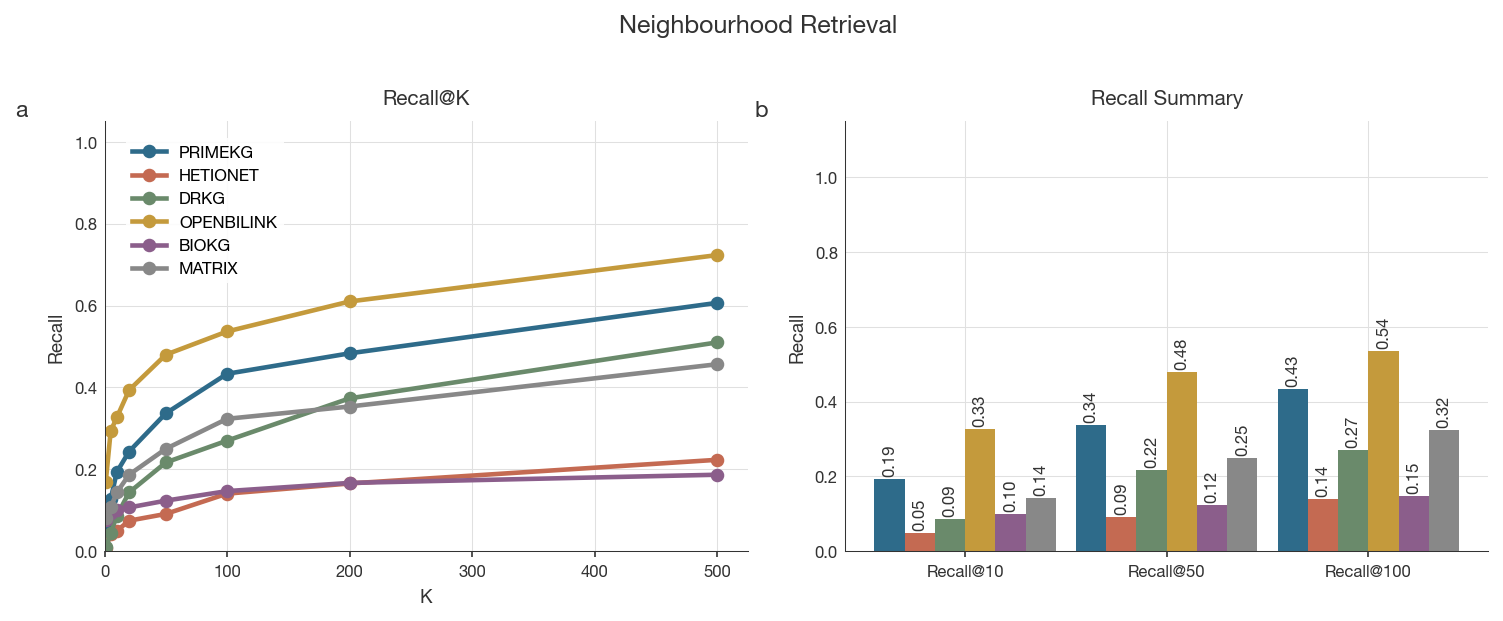

In [19]:
# Neighbourhood retrieval: Recall@K curves and summary bars
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel a: Recall@K curves
ax = axes[0]
k_range = [1, 5, 10, 20, 50, 100, 200, 500]

for i, name in enumerate(LOADED):
    if name not in target_results: continue
    ranks = target_results[name]['ranks']
    recall_at_k = [np.mean(ranks <= k) for k in k_range]
    ax.plot(k_range, recall_at_k, 'o-', color=KG_COLORS[name],
            lw=2.2, markersize=5.5, label=name.upper())

# Annotate K=10 values in a staggered column
k10_vals = {}
for name in LOADED:
    if name not in target_results: continue
    ranks = target_results[name]['ranks']
    k10_vals[name] = np.mean(ranks <= 10)

sorted_kgs = sorted(k10_vals.keys(), key=lambda n: k10_vals[n], reverse=True)

clean_ax(ax, title='Recall@K', xlabel='K', ylabel='Recall')
ax.set_xlim(0, max(k_range) * 1.05)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none',
          framealpha=0.9, loc='upper left', bbox_to_anchor=(0.02, 0.98))
_style_left_spine(ax)
panel_label(ax, 'a')

# Panel b: Recall@10 / @50 / @100 grouped bars
ax = axes[1]
ks     = ['recall@10', 'recall@50', 'recall@100']
labels = ['Recall@10', 'Recall@50', 'Recall@100']
shown  = [n for n in LOADED if n in target_results]
x      = np.arange(len(ks))
w      = 0.15
n_kgs  = len(shown)
for i, name in enumerate(shown):
    vals = [target_results[name][k] for k in ks]
    bars = ax.bar(x + i * w, vals, w, label=name.upper(),
                  color=KG_COLORS[name], edgecolor='none', linewidth=0)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{v:.2f}', ha='center', fontsize=8, color=TEXT_COLOR,
                rotation=90 if n_kgs > 4 else 0)
ax.set_xticks(x + w * (n_kgs - 1) / 2)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.15)
clean_ax(ax, title='Recall Summary', ylabel='Recall')
_style_left_spine(ax)
panel_label(ax, 'b')

plt.suptitle('Neighbourhood Retrieval',
             fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '06_neighbourhood_retrieval')
plt.show()

## 3. Multi-hop Reasoning

Given a known (drug, disease) therapeutic pair with a known mechanistic target gene, can the graph structure identify the correct target as the most plausible intermediate node?

**Gold standard construction.** Drug→gene→disease triplets are constructed from two CTD (Comparative Toxicogenomics Database; Davis et al., 2025) curated datasets:
- **CTD chemical–gene interactions** — curated from primary literature with PubMed evidence
- **CTD gene–disease associations** — curated gene→disease links with direct evidence (marker/mechanism or therapeutic)

These are fully external to the three benchmark KGs. For each chemical with a curated gene interaction, and each gene with a curated disease association, we obtain a validated (drug, gene, disease) chain. Triplets are filtered to entities resolvable in each KG.

**Protocol.** For each (drug, target, disease) triplet:
1. Remove the drug→disease indication edge (prevent leakage).
2. Score every candidate gene $g$ in the KG's gene pool as a potential intermediate:
$$\text{score}(g) = \text{AA}(\text{drug}, g) \times \text{AA}(g, \text{disease})$$
3. Rank all candidate genes by score and record the rank of the **known target**.

**Metrics:** Hits@100 (scored sub-metric), plus MRR and Hits@10 for characterisation.

**Sampling.** Up to 500 triplets per KG are sampled to keep runtime tractable.

> Davis, A.P. et al. Comparative Toxicogenomics Database's 20th anniversary: update 2025. *Nucleic Acids Res.* **53**, D1328 (2025).

In [20]:
# Build CTD-based multi-hop gold standard
import gzip

# ── Load CTD chemical-gene interactions (human only) ─────────────────
ctd_cg_rows = []
with gzip.open(BASE / 'data/gold_standards/CTD_chem_gene_ixns.tsv.gz', 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if len(parts) >= 7 and parts[6] == 'Homo sapiens':
            ctd_cg_rows.append({
                'chem_name':  parts[0].lower(),
                'chem_id':    parts[1],       # MESH ID
                'gene_symbol': parts[3],
                'gene_id':    int(parts[4]),   # NCBI gene ID
            })
ctd_cg = pd.DataFrame(ctd_cg_rows).drop_duplicates(subset=['chem_name', 'gene_id'])
print(f'CTD chem-gene (human, deduplicated): {len(ctd_cg):,} pairs  '
      f'({ctd_cg["chem_name"].nunique():,} chemicals, {ctd_cg["gene_id"].nunique():,} genes)')

# ── Load CTD gene-disease associations (direct evidence only) ────────
ctd_gd_rows = []
with gzip.open(BASE / 'data/gold_standards/CTD_curated_genes_diseases.tsv.gz', 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if len(parts) >= 5 and parts[4] in ('marker/mechanism', 'therapeutic'):
            ctd_gd_rows.append({
                'gene_symbol': parts[0],
                'gene_id':     int(parts[1]),
                'disease_name': parts[2].lower(),
                'disease_id':  parts[3],       # MESH:xxx or OMIM:xxx
            })
ctd_gd = pd.DataFrame(ctd_gd_rows).drop_duplicates(subset=['gene_id', 'disease_id'])
print(f'CTD gene-disease (direct evidence):  {len(ctd_gd):,} pairs  '
      f'({ctd_gd["gene_id"].nunique():,} genes, {ctd_gd["disease_id"].nunique():,} diseases)')

# ── Join: chem → gene → disease triplets ─────────────────────────────
ctd_triplets = ctd_cg.merge(ctd_gd, on='gene_id', suffixes=('_cg', '_gd'))
print(f'CTD triplets (chem→gene→disease):    {len(ctd_triplets):,} '
      f'({ctd_triplets["chem_name"].nunique():,} drugs, '
      f'{ctd_triplets["gene_id"].nunique():,} genes, '
      f'{ctd_triplets["disease_id"].nunique():,} diseases)')

CTD chem-gene (human, deduplicated): 821,913 pairs  (11,035 chemicals, 28,579 genes)
CTD gene-disease (direct evidence):  33,946 pairs  (9,109 genes, 5,845 diseases)
CTD triplets (chem→gene→disease):    4,702,728 (10,908 drugs, 8,719 genes, 5,827 diseases)


In [21]:

# ── Multi-hop: resolve CTD triplets to KG node indices ───────────────
N_MULTIHOP = 500  # max triplets sampled per KG

# ── Load MESH→DOID mapping once (used for ID-based disease resolution)
_m2d_raw = pd.read_csv(BASE / 'data/gold_standards/mesh_to_doid.csv', on_bad_lines='skip')
_m2d_raw['mesh_clean'] = _m2d_raw['mesh_id'].str.split(' ').str[0]
MESH_TO_DOID = dict(zip(_m2d_raw['mesh_clean'], _m2d_raw['doid']))  # 'MESH:D*' → 'DOID:*'

# ── Load DrugBank names once ─────────────────────────────────────────────────────
# Any KG whose nodes carry a drugbank_id column gets human-readable drug names
# injected into its lookup automatically (no KG-specific hardcoding needed).
_db_names_df = pd.read_csv(BASE / 'data/gold_standards/drugbank_drugs.csv',
                           usecols=['drugbank_id', 'name'])
_DRUGBANK_NAME_MAP = dict(zip(_db_names_df['drugbank_id'],
                               _db_names_df['name'].str.lower()))


def _strip_type_prefix(raw: str) -> str:
    """Strip 'TypeName::' prefix from a node ID string.

    KGs store node identifiers with a type prefix in id_map
    (e.g. 'Gene::2157', 'Disease::DOID:10021', 'Compound::DB00001').
    This returns the bare identifier after the first '::'.
    If no '::' is present the original string is returned unchanged.
    """
    return raw.split('::', 1)[1] if '::' in raw else raw


def _build_gene_lookup(name: str) -> dict:
    """Build NCBI-int → node-idx lookup for gene/protein nodes.

    Strategy (tried in order for every gene node):
      1. Strip type prefix from node_id_map value, then int-parse
         → works for PrimeKG ('9796'), Hetionet ('Gene::1' → '1'), DRKG ('Gene::2157')
      2. int-parse node_name_map value directly
         → works when name is already a bare NCBI int (DRKG name = '2157')
      3. Store uppercased node_name as a gene-symbol key
         → fallback for Hetionet (name = 'A1BG') and PrimeKG (name = 'PHYHIP')
    """
    nm       = maps[name]['node_name_map']
    id_map   = maps[name].get('node_id_map', {})
    gene_idx = kg_entity_sets[name].get('gene', set())

    lookup = {}
    for idx in gene_idx:
        # Strategy 1: strip prefix from full node ID, then int-parse
        raw_id = id_map.get(idx, '')
        bare   = _strip_type_prefix(raw_id)
        try:
            lookup[int(bare)] = idx
        except (ValueError, TypeError):
            pass

        # Strategy 2: int-parse node name directly (DRKG name = '2157')
        node_name = nm.get(idx, '')
        if node_name:
            try:
                lookup[int(node_name)] = idx
            except (ValueError, TypeError):
                pass
            # Strategy 3: gene symbol (uppercase string key)
            lookup[node_name.upper()] = idx

    return lookup


def _build_drug_lookup(name: str) -> tuple:
    """Return (name_lookup, id_lookup) dicts for drug/compound nodes.

    name_lookup : lowercased node name → idx   (works for PrimeKG, Hetionet)
    id_lookup   : raw node name → idx          (for DRKG: name = 'MESH:C...', 'DB...')
                  Also strip type prefix version for safety.
    CTD lookup key = 'MESH:' + chem_id, so id_lookup keyed by raw name handles DRKG.
    """
    nm = maps[name]['node_name_map']
    tm = maps[name]['node_type_map']
    dt = kg_drug_type(name)

    name_lookup = {}
    id_lookup   = {}
    for idx in nm:
        if tm.get(idx) != dt:
            continue
        node_name = str(nm[idx])
        name_lookup[node_name.lower()] = idx   # human-name key
        id_lookup[node_name]           = idx   # raw ID key (e.g. 'MESH:C010161')
        # Also store prefix-stripped version for safety
        bare = _strip_type_prefix(node_name)
        id_lookup[bare] = idx

    # KG-agnostic: if this KG's nodes carry a drugbank_id column, inject
    # DrugBank human names as additional lookup keys.  Handles any KG whose
    # native node IDs differ from CTD chemical names (e.g. PubChem CIDs).
    nodes_df = kgs[name]['nodes']
    if 'drugbank_id' in nodes_df.columns:
        drug_nodes = nodes_df[nodes_df['type'] == dt][['idx', 'drugbank_id']]
        for _, row in drug_nodes.iterrows():
            db_name = _DRUGBANK_NAME_MAP.get(str(row['drugbank_id']), '')
            if db_name:
                name_lookup[db_name] = int(row['idx'])

    return name_lookup, id_lookup


def _build_disease_lookup(name: str) -> tuple:
    """Return (name_lookup, id_lookup) dicts for disease nodes.

    name_lookup : lowercased node name → idx   (works for PrimeKG, Hetionet)
    id_lookup   : DOID string → idx            (works for DRKG whose names are 'DOID:*')
                  Built by stripping type prefix from node_id_map values.
    MESH→DOID chain: CTD disease_id (MESH:D*) → DOID (via MESH_TO_DOID) → idx
    """
    nm     = maps[name]['node_name_map']
    tm     = maps[name]['node_type_map']
    id_map = maps[name].get('node_id_map', {})
    dis_t  = kg_disease_type(name)

    name_lookup = {}
    id_lookup   = {}
    for idx in nm:
        if tm.get(idx) != dis_t:
            continue
        node_name = str(nm[idx])
        name_lookup[node_name.lower()] = idx

        # Key by stripped id_map value (e.g. Hetionet: 'Disease::DOID:10021' → 'DOID:10021')
        raw_id = id_map.get(idx, '')
        bare   = _strip_type_prefix(raw_id)
        if bare:
            id_lookup[bare] = idx

        # Also key by node name directly (DRKG name = 'DOID:10021')
        id_lookup[node_name] = idx

    return name_lookup, id_lookup


def resolve_ctd_triplets(name: str, ctd_triplets_df: pd.DataFrame) -> pd.DataFrame:
    """Resolve CTD (drug, gene, disease) triplets to node indices for one KG.

    Fully KG-agnostic: no hardcoded KG names, prefixes, or format assumptions.
    All node ID parsing is handled by _strip_type_prefix + fallback strategies.

    Resolution order
    ────────────────
    Gene    : NCBI int (from id_map stripped) → NCBI int (from name) → gene symbol
    Drug    : lowercased chem_name → 'MESH:' + chem_id (ID-based, e.g. DRKG)
    Disease : lowercased disease_name → DOID via MESH_TO_DOID (ID-based, e.g. DRKG)
    """
    G           = graphs[name]
    graph_nodes = set(G.nodes())

    gene_lookup                    = _build_gene_lookup(name)
    drug_name_lookup, drug_id_lkp  = _build_drug_lookup(name)
    dis_name_lookup,  dis_id_lkp   = _build_disease_lookup(name)

    df = ctd_triplets_df.copy()

    # ── Gene ─────────────────────────────────────────────────────────
    df['gene_idx'] = df['gene_id'].map(gene_lookup)           # NCBI int key
    miss = df['gene_idx'].isna()
    if miss.any() and 'gene_symbol_cg' in df.columns:
        df.loc[miss, 'gene_idx'] = (
            df.loc[miss, 'gene_symbol_cg'].str.upper().map(gene_lookup)
        )

    # ── Drug ─────────────────────────────────────────────────────────
    df['drug_idx'] = df['chem_name'].str.lower().map(drug_name_lookup)
    miss = df['drug_idx'].isna()
    if miss.any() and 'chem_id' in df.columns:
        # Construct 'MESH:' + chem_id → matches DRKG drug node names like 'MESH:C010161'
        df.loc[miss, 'drug_idx'] = (
            ('MESH:' + df.loc[miss, 'chem_id'].astype(str)).map(drug_id_lkp)
        )

    # ── Disease ──────────────────────────────────────────────────────
    df['disease_idx'] = df['disease_name'].str.lower().map(dis_name_lookup)
    miss = df['disease_idx'].isna()
    if miss.any() and 'disease_id' in df.columns:
        # MESH:D* → DOID:* → node idx  (covers DRKG whose names are 'DOID:*')
        doid = df.loc[miss, 'disease_id'].map(MESH_TO_DOID)
        df.loc[miss, 'disease_idx'] = doid.map(dis_id_lkp)

    # ── Diagnostics ──────────────────────────────────────────────────
    n_total = len(df)
    n_gene  = df['gene_idx'].notna().sum()
    n_drug  = df['drug_idx'].notna().sum()
    n_dis   = df['disease_idx'].notna().sum()
    print(f'  {name} resolution: gene={n_gene:,}/{n_total:,} '
          f'drug={n_drug:,}/{n_total:,} disease={n_dis:,}/{n_total:,}')

    # ── Filter and type-cast ─────────────────────────────────────────
    df = df.dropna(subset=['gene_idx', 'drug_idx', 'disease_idx'])
    df[['gene_idx', 'drug_idx', 'disease_idx']] = (
        df[['gene_idx', 'drug_idx', 'disease_idx']].astype(int)
    )
    mask = (
        df['drug_idx'].isin(graph_nodes) &
        df['gene_idx'].isin(graph_nodes) &
        df['disease_idx'].isin(graph_nodes)
    )
    df = df[mask]

    # ── Normalise output columns ──────────────────────────────────────
    rename = {'chem_name': 'drug_name'}
    if 'gene_symbol_cg' in df.columns:
        rename['gene_symbol_cg'] = 'gene_symbol'
    df = df.rename(columns=rename)
    # Handle disease_name suffix from merge
    if 'disease_name' not in df.columns:
        for c in df.columns:
            if c.startswith('disease_name'):
                df = df.rename(columns={c: 'disease_name'})
                break

    out_cols  = ['drug_name', 'gene_symbol', 'disease_name',
                 'drug_idx', 'gene_idx', 'disease_idx']
    available = [c for c in out_cols if c in df.columns]
    return df[available].drop_duplicates(subset=['drug_idx', 'gene_idx', 'disease_idx'])


# ── Run resolution for all KGs ────────────────────────────────────────
ctd_resolved = {}
for name in tqdm(LOADED, desc='Resolving CTD triplets'):
    t0 = time.time()
    df = resolve_ctd_triplets(name, ctd_triplets)

    # Stratified sample: at most 5 triplets per drug, total ≤ N_MULTIHOP
    if len(df) > N_MULTIHOP:
        parts = [grp.sample(min(len(grp), 5), random_state=rng)
                 for _, grp in df.groupby('drug_idx')]
        sampled = pd.concat(parts, ignore_index=True)
        if len(sampled) > N_MULTIHOP:
            sampled = sampled.sample(N_MULTIHOP, random_state=rng)
        df = sampled

    ctd_resolved[name] = df
    print(f'  → {len(df):,} triplets sampled  '
          f'({df["drug_idx"].nunique():,} drugs, '
          f'{df["gene_idx"].nunique():,} genes, '
          f'{df["disease_idx"].nunique():,} diseases)  '
          f'[{time.time()-t0:.1f}s]')


Resolving CTD triplets:   0%|          | 0/6 [00:00<?, ?it/s]

  primekg resolution: gene=4,700,311/4,702,728 drug=1,593,028/4,702,728 disease=1,146,049/4,702,728
  → 500 triplets sampled  (457 drugs, 216 genes, 173 diseases)  [2.0s]
  hetionet resolution: gene=4,674,717/4,702,728 drug=929,536/4,702,728 disease=813,004/4,702,728
  → 500 triplets sampled  (395 drugs, 225 genes, 77 diseases)  [1.9s]
  drkg resolution: gene=4,700,595/4,702,728 drug=1,594,475/4,702,728 disease=774,784/4,702,728
  → 500 triplets sampled  (464 drugs, 212 genes, 61 diseases)  [2.1s]
  openbilink resolution: gene=4,697,467/4,702,728 drug=1,455,256/4,702,728 disease=2,981,651/4,702,728
  → 500 triplets sampled  (437 drugs, 247 genes, 253 diseases)  [2.8s]
  biokg resolution: gene=2,649,228/4,702,728 drug=1,397,776/4,702,728 disease=4,473,228/4,702,728
  → 500 triplets sampled  (441 drugs, 185 genes, 292 diseases)  [2.1s]
  matrix resolution: gene=4,702,577/4,702,728 drug=3,001,622/4,702,728 disease=1,268,053/4,702,728
  → 500 triplets sampled  (478 drugs, 212 genes, 192 di

In [22]:
# Multi-hop evaluation: rank known target gene among all candidate genes
# Score(g) = AA(drug, g) * AA(g, disease)  for each candidate gene g
multihop_results = {}

for name in LOADED:
    triplets  = ctd_resolved[name]
    G         = graphs[name]
    gene_list = kg_gene_lists[name]

    if len(triplets) == 0:
        multihop_results[name] = {
            'hits@10': 0.0, 'hits@50': 0.0, 'hits@100': 0.0,
            'mrr': 0.0, 'mean_rank': 0.0, 'median_rank': 0.0,
            'n_evaluated': 0, 'ranks': np.array([]), 'pool_size': len(gene_list),
        }
        print(f'{name:12s}: no resolved triplets — skipping')
        continue

    # Precompute inverse log-degree for Adamic-Adar
    inv_log_deg = {
        n: (1.0 / np.log(G.degree(n)) if G.degree(n) > 1 else 0.0)
        for n in G.nodes()
    }

    ranks, h10, h50, h100 = [], [], [], []

    for i, (_, row) in enumerate(triplets.iterrows()):
        drug_idx    = int(row['drug_idx'])
        gene_idx    = int(row['gene_idx'])
        disease_idx = int(row['disease_idx'])

        # Remove drug→disease edge to prevent leakage (always restore via try-finally)
        had_edge  = G.has_edge(drug_idx, disease_idx)
        edge_data = G.edges[drug_idx, disease_idx] if had_edge else None
        try:
            if had_edge:
                G.remove_edge(drug_idx, disease_idx)

            drug_nbrs    = set(G.neighbors(drug_idx))
            disease_nbrs = set(G.neighbors(disease_idx))

            # Score each candidate gene: AA(drug, g) * AA(g, disease)
            scores = np.zeros(len(gene_list))
            for j, g in enumerate(gene_list):
                if not G.has_node(g):
                    continue
                g_nbrs = set(G.neighbors(g))
                aa_drug = sum(inv_log_deg[w] for w in drug_nbrs & g_nbrs)
                aa_dis  = sum(inv_log_deg[w] for w in disease_nbrs & g_nbrs)
                scores[j] = aa_drug * aa_dis
        finally:
            # Always restore the edge to avoid corrupting the shared graph
            if had_edge:
                G.add_edge(drug_idx, disease_idx, **(edge_data or {}))

        # Rank the known target
        if gene_idx in gene_list:
            target_j = gene_list.index(gene_idx)
            rank = int(np.sum(scores >= scores[target_j]))  # 1-indexed, ties conservative
            ranks.append(rank)
            h10.append(1 if rank <= 10 else 0)
            h50.append(1 if rank <= 50 else 0)
            h100.append(1 if rank <= 100 else 0)

        if (i + 1) % 50 == 0:
            print(f'  {name}: {i+1}/{len(triplets)} evaluated...')

    ranks = np.array(ranks)
    multihop_results[name] = {
        'hits@10':     np.mean(h10)  if h10 else 0.0,
        'hits@50':     np.mean(h50)  if h50 else 0.0,
        'hits@100':    np.mean(h100) if h100 else 0.0,
        'mrr':         np.mean(1.0 / ranks) if len(ranks) else 0.0,
        'mean_rank':   np.mean(ranks) if len(ranks) else 0.0,
        'median_rank': np.median(ranks) if len(ranks) else 0.0,
        'n_evaluated': len(ranks),
        'ranks':       ranks,
        'pool_size':   len(gene_list),
    }
    _mrr24   = float(np.mean(1.0 / ranks)) if len(ranks) else 0.0
    _med24   = float(np.median(ranks))       if len(ranks) else 0.0
    print(f'{name:12s}: Hits@10={np.mean(h10) if h10 else 0.0:.3f}  '
          f'@50={np.mean(h50) if h50 else 0.0:.3f}  '
          f'@100={np.mean(h100) if h100 else 0.0:.3f}  MRR={_mrr24:.4f}  '
          f'median rank={_med24:.0f}/{len(gene_list):,}  '
          f'({len(ranks)} evaluated)')

  primekg: 50/500 evaluated...
  primekg: 100/500 evaluated...
  primekg: 150/500 evaluated...
  primekg: 200/500 evaluated...
  primekg: 250/500 evaluated...
  primekg: 300/500 evaluated...
  primekg: 350/500 evaluated...
  primekg: 400/500 evaluated...
  primekg: 450/500 evaluated...
  primekg: 500/500 evaluated...
primekg     : Hits@10=0.104  @50=0.290  @100=0.364  MRR=0.0582  median rank=27671/27,671  (500 evaluated)
  hetionet: 50/500 evaluated...
  hetionet: 100/500 evaluated...
  hetionet: 150/500 evaluated...
  hetionet: 200/500 evaluated...
  hetionet: 250/500 evaluated...
  hetionet: 300/500 evaluated...
  hetionet: 350/500 evaluated...
  hetionet: 400/500 evaluated...
  hetionet: 450/500 evaluated...
  hetionet: 500/500 evaluated...
hetionet    : Hits@10=0.060  @50=0.144  @100=0.190  MRR=0.0258  median rank=1506/20,945  (500 evaluated)
  drkg: 50/500 evaluated...
  drkg: 100/500 evaluated...
  drkg: 150/500 evaluated...
  drkg: 200/500 evaluated...
  drkg: 250/500 evaluated.

In [23]:
# ── Bootstrap 95% CIs for multi-hop reasoning (Hits@100) ─────────────
multihop_ci = {}
print(f'{"KG":12s}  {"Hits@100":>10s}  {"95% CI":>16s}')
print('-' * 44)
for name in LOADED:
    ranks = multihop_results[name]['ranks']
    if len(ranks) < 10:
        multihop_ci[name] = (multihop_results[name]['hits@100'], np.nan, np.nan)
        continue
    boots = []
    for _ in range(N_BOOT):
        bi = BOOT_RNG.choice(len(ranks), size=len(ranks), replace=True)
        boots.append(np.mean(ranks[bi] <= 100))
    point = np.mean(ranks <= 100)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    multihop_ci[name] = (float(point), float(lo), float(hi))
    print(f'{name:12s}  {point:10.4f}  [{lo:.4f}, {hi:.4f}]')


KG              Hits@100            95% CI
--------------------------------------------
primekg           0.3640  [0.3220, 0.4020]
hetionet          0.1900  [0.1560, 0.2260]
drkg              0.3500  [0.3060, 0.3900]
openbilink        0.3500  [0.3060, 0.3920]
biokg             0.0900  [0.0660, 0.1140]
matrix            0.1940  [0.1600, 0.2300]


  → Saved: 06_multihop_reasoning.pdf / .png


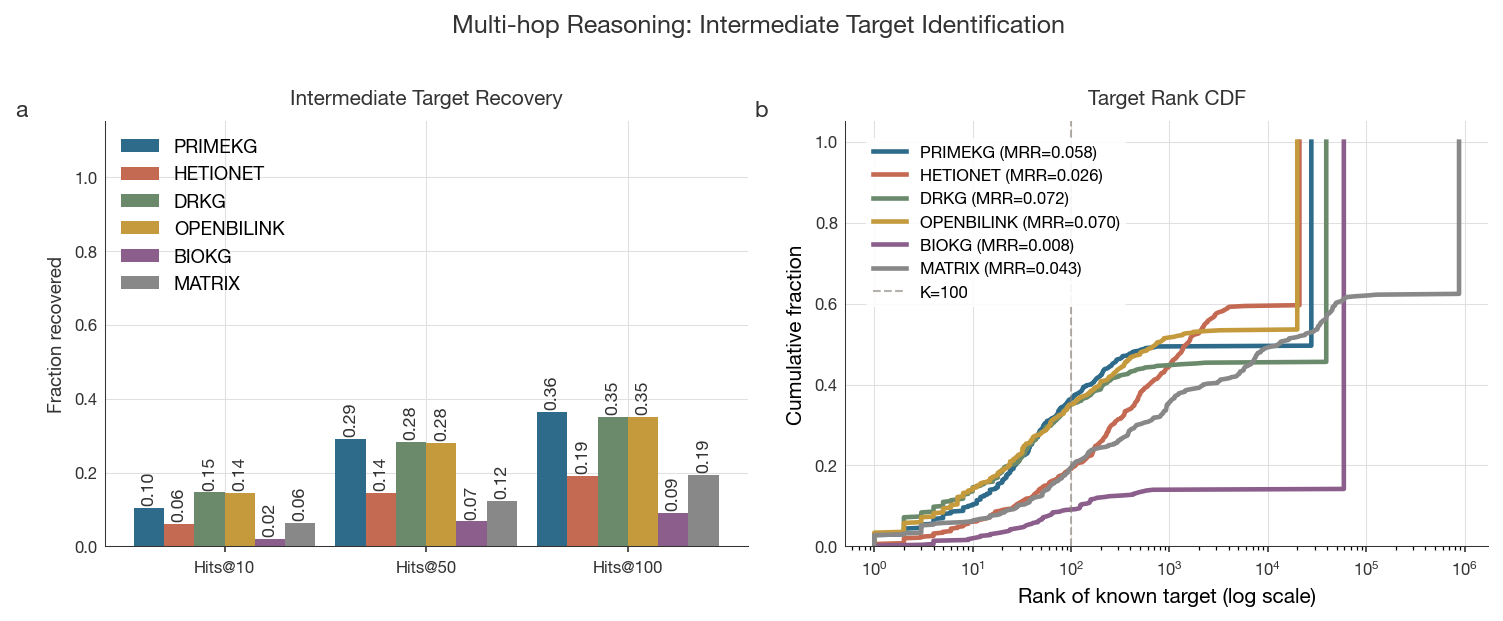

In [24]:
# Multi-hop reasoning: summary visualization
shown_mh = [n for n in LOADED if n in multihop_results and multihop_results[n]['n_evaluated'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel a: Hits@K grouped bars
ax = axes[0]
ks     = ['hits@10', 'hits@50', 'hits@100']
labels = ['Hits@10', 'Hits@50', 'Hits@100']
x      = np.arange(len(ks))
w      = 0.15
n_kgs  = len(shown_mh)

for i, name in enumerate(shown_mh):
    vals = [multihop_results[name][k] for k in ks]
    bars = ax.bar(x + i * w, vals, w, label=name.upper(),
                  color=KG_COLORS[name], edgecolor='none', linewidth=0)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{v:.2f}', ha='center', fontsize=8.5, color=TEXT_COLOR,
                rotation=90)

ax.set_xticks(x + w * (n_kgs - 1) / 2)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.15)
clean_ax(ax, title='Intermediate Target Recovery', ylabel='Fraction recovered')
ax.legend(fontsize=9, frameon=False, loc='upper left')
_style_left_spine(ax)
panel_label(ax, 'a')

# Panel b: Rank distribution (log scale)
ax = axes[1]
for name in shown_mh:
    r = multihop_results[name]['ranks']
    sorted_r = np.sort(r)
    cdf = np.arange(1, len(sorted_r) + 1) / len(sorted_r)
    ax.plot(sorted_r, cdf, '-', color=KG_COLORS[name], lw=2.2,
            label=f'{name.upper()} (MRR={multihop_results[name]["mrr"]:.3f})')
ax.set_xscale('log')
ax.set_xlabel('Rank of known target (log scale)', fontsize=10)
ax.set_ylabel('Cumulative fraction', fontsize=10)
ax.set_ylim(0, 1.05)
ax.axvline(100, color='#868074', ls='--', lw=1.0, alpha=0.6, label='K=100')
clean_ax(ax, title='Target Rank CDF')
ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none',
          framealpha=0.9, loc='upper left', bbox_to_anchor=(0.02, 0.98))
_style_left_spine(ax)
panel_label(ax, 'b')

plt.suptitle('Multi-hop Reasoning: Intermediate Target Identification',
             fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)
plt.tight_layout()
save_fig(fig, FIGS, '06_multihop_reasoning')
plt.show()

### Checkpoint

In [25]:
# Checkpoint - save scalar results for downstream notebooks (with bootstrap CIs)
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# ── 1. Link prediction (type-constrained): Adamic-Adar AUROC ─────────
lp_tc_scores = {}
lp_tc_ci = {}        # NEW: CI bounds
lp_all_heuristics = {}
for name in LOADED:
    aa_result = link_results.get((name, PRIMARY_HEURISTIC, 'type-constrained'), {})
    lp_tc_scores[name] = round(aa_result.get('auroc', 0.0) or 0.0, 4)
    lp_tc_ci[name] = {
        'auroc_ci_lo': round(aa_result.get('auroc_ci_lo', np.nan), 4),
        'auroc_ci_hi': round(aa_result.get('auroc_ci_hi', np.nan), 4),
        'auprc_ci_lo': round(aa_result.get('auprc_ci_lo', np.nan), 4),
        'auprc_ci_hi': round(aa_result.get('auprc_ci_hi', np.nan), 4),
    }
    lp_all_heuristics[name] = {
        h: round(link_results.get((name, h, 'type-constrained'), {}).get('auroc', 0.0) or 0.0, 4)
        for h in SCORERS
    }

print(f'Link prediction — type-constrained AUROC ({PRIMARY_HEURISTIC}, primary):')
for kg, s in lp_tc_scores.items():
    ci = lp_tc_ci[kg]
    print(f'  {kg:12s}: {s:.4f}  95% CI [{ci["auroc_ci_lo"]:.4f}, {ci["auroc_ci_hi"]:.4f}]')

# ── 2. Neighbourhood retrieval: Recall@100 ───────────────────────────
nbhd_scores = {}
for name in LOADED:
    if name in target_results:
        nbhd_scores[name] = round(target_results[name]['recall@100'], 4)
    else:
        nbhd_scores[name] = 0.0

print('\nNeighbourhood retrieval — Recall@100:')
for kg, s in nbhd_scores.items():
    ci = nbhd_ci.get(kg, (s, np.nan, np.nan))
    print(f'  {kg:12s}: {s:.4f}  95% CI [{ci[1]:.4f}, {ci[2]:.4f}]')

# ── 3. Multi-hop reasoning: Hits@100 ─────────────────────────────────
multihop_scores = {}
for name in LOADED:
    if name in multihop_results and multihop_results[name]['n_evaluated'] > 0:
        multihop_scores[name] = round(multihop_results[name]['hits@100'], 4)
    else:
        multihop_scores[name] = 0.0

print('\nMulti-hop reasoning — Hits@100:')
for kg, s in multihop_scores.items():
    ci = multihop_ci.get(kg, (s, np.nan, np.nan))
    print(f'  {kg:12s}: {s:.4f}  95% CI [{ci[1]:.4f}, {ci[2]:.4f}]')

# ── 4. Summary = equal-weighted mean of 3 sub-scores ─────────────────
sub_scores = {}
summary_scores = {}
for name in LOADED:
    lp = lp_tc_scores[name]
    nr = nbhd_scores[name]
    mh = multihop_scores[name]
    sub_scores[name] = {
        'link_prediction':    lp,
        'nbhd_retrieval':     nr,
        'multihop_reasoning': mh,
    }
    summary_scores[name] = round((lp + nr + mh) / 3.0, 4)

print(f'\nTask Performance (3 sub-metrics, equal-weighted):')
for name in LOADED:
    ss = sub_scores[name]
    print(f'  {name:12s}: {summary_scores[name]:.4f}  '
          f'(link_pred={ss["link_prediction"]:.4f}, '
          f'nbhd={ss["nbhd_retrieval"]:.4f}, '
          f'multihop={ss["multihop_reasoning"]:.4f})')

# ── 5. Serialise and save ────────────────────────────────────────────
link_records = [
    {'kg': k[0], 'heuristic': k[1], 'strategy': k[2],
     **{mk: mv for mk, mv in v.items() if isinstance(mv, (int, float, str)) or mv is None}}
    for k, v in link_results.items()
]

nbhd_scalars = {
    name: {k: v for k, v in tr.items() if k != 'ranks'}
    for name, tr in target_results.items()
}
# Inject CIs into nbhd_scalars
for name in LOADED:
    ci = nbhd_ci.get(name, (np.nan, np.nan, np.nan))
    nbhd_scalars[name]['recall@100_ci_lo'] = ci[1]
    nbhd_scalars[name]['recall@100_ci_hi'] = ci[2]

multihop_scalars = {
    name: {k: v for k, v in mr.items() if k != 'ranks'}
    for name, mr in multihop_results.items()
}
# Inject CIs into multihop_scalars
for name in LOADED:
    ci = multihop_ci.get(name, (np.nan, np.nan, np.nan))
    multihop_scalars[name]['hits@100_ci_lo'] = ci[1]
    multihop_scalars[name]['hits@100_ci_hi'] = ci[2]

ckpt = {
    'summary_scores':      summary_scores,
    'sub_scores':          sub_scores,
    'primary_heuristic':   PRIMARY_HEURISTIC,
    'lp_all_heuristics':   lp_all_heuristics,
    'lp_tc_ci':            lp_tc_ci,             # NEW
    'link_records':        link_records,          # now includes CI fields
    'nbhd_scalars':        nbhd_scalars,          # now includes CI fields
    'multihop_scalars':    multihop_scalars,       # now includes CI fields
    'pval_matrix':         pval_matrix.to_dict(),  # NEW: permutation test results
}
out = CKPT_DIR / '06_predictive_performance.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)
print(f'\nCheckpoint saved -> {out}')


Link prediction — type-constrained AUROC (Adamic-Adar, primary):
  primekg     : 0.9464  95% CI [0.9359, 0.9555]
  hetionet    : 0.8745  95% CI [0.8246, 0.9166]
  drkg        : 0.9285  95% CI [0.9117, 0.9431]
  openbilink  : 0.7596  95% CI [0.7418, 0.7785]
  biokg       : 0.8980  95% CI [0.8933, 0.9027]
  matrix      : 0.9959  95% CI [0.9955, 0.9964]

Neighbourhood retrieval — Recall@100:
  primekg     : 0.4333  95% CI [0.3767, 0.4900]
  hetionet    : 0.1405  95% CI [0.0826, 0.1983]
  drkg        : 0.2700  95% CI [0.2200, 0.3200]
  openbilink  : 0.5367  95% CI [0.4767, 0.6000]
  biokg       : 0.1467  95% CI [0.1100, 0.1867]
  matrix      : 0.3233  95% CI [0.2733, 0.3800]

Multi-hop reasoning — Hits@100:
  primekg     : 0.3640  95% CI [0.3220, 0.4020]
  hetionet    : 0.1900  95% CI [0.1560, 0.2260]
  drkg        : 0.3500  95% CI [0.3060, 0.3900]
  openbilink  : 0.3500  95% CI [0.3060, 0.3920]
  biokg       : 0.0900  95% CI [0.0660, 0.1140]
  matrix      : 0.1940  95% CI [0.1600, 0.2300]

### Statistical methodology

Uncertainty was quantified using the non-parametric percentile bootstrap 
(Efron & Tibshirani, 1993). For each metric and KG, 1,000 bootstrap samples 
were drawn with **stratified resampling** — positives and negatives were resampled 
independently to preserve the class ratio in every bootstrap sample — and the 
2.5th and 97.5th percentiles of the bootstrap distribution define the 95% 
confidence interval. Pairwise differences in AUROC between KGs were assessed 
using a two-sided permutation test (1,000 permutations) with Bonferroni 
correction for $\binom{5}{2} = 10$ pairwise comparisons (family-wise 
$\alpha = 0.05$). For neighbourhood retrieval (Recall@100) and multi-hop 
reasoning (Hits@100), bootstrap CIs were computed by resampling the per-query 
rank vectors.


## Dimension Score

The task performance dimension score combines three sub-metrics:

$$\text{Task Performance} = \frac{1}{3}\left(\text{Link Prediction} + \text{Neighbourhood Retrieval} + \text{Multi-hop Reasoning}\right)$$

**Link prediction** is the AUROC achieved by Adamic-Adar under type-constrained negative sampling — the pre-specified primary heuristic. Adamic-Adar is preferred over Common Neighbors and Jaccard because it down-weights shared neighbours that are high-degree hubs ($\sum_{w \in N(u) \cap N(v)} 1/\log|N(w)|$), making it more biologically motivated: a low-degree shared intermediate node represents more specific structural evidence than a highly connected hub. Results for all three heuristics are stored in `lp_all_heuristics` in the checkpoint and reported in the supplementary table.

**Neighbourhood retrieval** is Recall@100 from a leave-one-out evaluation: for each disease with $\geq 5$ known gene targets, one target is held out and ranked against the full gene pool using Adamic-Adar.

**Multi-hop reasoning** is Hits@100 from intermediate target identification using CTD gold-standard (drug, gene, disease) triplets: all candidate genes are scored as potential intermediates via $\text{AA}(\text{drug}, g) \times \text{AA}(g, \text{disease})$, and the fraction of cases where the known target ranks in the top 100 is reported.

In [26]:
# Memory cleanup - free state before the next notebook in the pipeline.
_to_free = ['kgs', 'graphs', 'maps', 'preps',
            'kg_pos_pairs', 'kg_entity_sets', 'kg_drug_targets',
            'kg_disease_targets', 'kg_gene_lists', 'kg_disease_degree']
for _v in _to_free:
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()
print('Freed KG state from kernel memory.')

Freed KG state from kernel memory.
